In [1]:
# --- Step 1: Libraries and Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from scipy.sparse import issparse

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42


In [2]:
# --- Step 2: Data Loading and Preprocessing ---
data_path = 'data/bug_dataset_50k.csv'
if not os.path.exists(data_path):
    print("Dataset not found. Please ensure it is located at 'data/bug_dataset_50k.csv'")

df = pd.read_csv(data_path)
print(f"Original Dataset Shape: {df.shape}")

# Handle missing values
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')
if 'error_code' in df.columns:
    df['error_code'] = df['error_code'].fillna(0)

categorical_cols = ['bug_category', 'tech_stack', 'environment', 'developer_role', 'bug_domain']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.lower().str.strip()

# Merge title and description, and lowercase
df['full_text'] = (df['title'] + " " + df['description']).str.lower()

# Calculate word count for outlier detection
df['desc_word_count'] = df['full_text'].apply(lambda x: len(x.split()))

print("Data preprocessing complete.")


Original Dataset Shape: (50000, 14)


Data preprocessing complete.


In [3]:
# --- Step 3: Exploratory Data Analysis (EDA) & Outlier Handling ---
# Outlier Detection and Handling
Q1 = df['desc_word_count'].quantile(0.25)
Q3 = df['desc_word_count'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

initial_count = len(df)
df = df[df['desc_word_count'] <= upper_limit].copy()
print(f"Removed {initial_count - len(df)} outlier records based on text length. Remaining records: {len(df)}")


Removed 9261 outlier records based on text length. Remaining records: 40739


In [4]:
# --- Step 4: Train/Test Split & Pipeline Definition ---
# Encode Target
target_le = LabelEncoder()
df['target'] = target_le.fit_transform(df['severity'])

# Separate Features and Target
X = df.drop(columns=['severity', 'target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# Define ColumnTransformer for safe encoding and vectorization
transformers = [
    ('cat', OneHotEncoder(handle_unknown='ignore'), [col for col in categorical_cols if col in X.columns]),
    ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'full_text')
]
if 'error_code' in X.columns:
    transformers.append(('num', 'passthrough', ['error_code']))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Define pipelines
pipelines = {
    'Naive Bayes': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=chi2, k=2000)),
        ('classifier', MultinomialNB())
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=chi2, k=2000)),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=chi2, k=2000)),
        ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE))
    ])
}


Train samples: 32591, Test samples: 8148


In [5]:
# --- Step 5: Cross-Validation ---
print("Evaluating Models using 5-Fold Cross Validation...")
cv_results = []
for name, pipeline in pipelines.items():
    print(f"Running CV for {name}...")
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'Mean F1-Score': np.mean(scores),
        'Std Dev': np.std(scores)
    })

import IPython.display as display
display.display(pd.DataFrame(cv_results))


Evaluating Models using 5-Fold Cross Validation...
Running CV for Naive Bayes...


Running CV for Random Forest...


Running CV for XGBoost...


,Model,Mean F1-Score,Std Dev
0,Naive Bayes,1.0,0.0
1,Random Forest,1.0,0.0
2,XGBoost,1.0,0.0


In [6]:
# --- Step 6: Hyperparameter Tuning ---
print("Performing Hyperparameter Tuning using RandomizedSearchCV...")

# Random Forest Params
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, None],
    'classifier__min_samples_split': [2, 5]
}

# XGBoost Params
xgb_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 6]
}

tuned_pipelines = {'Naive Bayes': pipelines['Naive Bayes']} # NB doesn't need much tuning here

print("Tuning Random Forest...")
rf_search = RandomizedSearchCV(pipelines['Random Forest'], rf_param_grid, n_iter=3, cv=3, scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
tuned_pipelines['Random Forest'] = rf_search.best_estimator_
print(f"Best RF Params: {rf_search.best_params_}")

print("Tuning XGBoost...")
xgb_search = RandomizedSearchCV(pipelines['XGBoost'], xgb_param_grid, n_iter=3, cv=3, scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
tuned_pipelines['XGBoost'] = xgb_search.best_estimator_
print(f"Best XGB Params: {xgb_search.best_params_}")


Performing Hyperparameter Tuning using RandomizedSearchCV...
Tuning Random Forest...


Best RF Params: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 10}
Tuning XGBoost...


Best XGB Params: {'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}


Naive Bayes Test F1-Score: 1.0000


Random Forest Test F1-Score: 1.0000


XGBoost Test F1-Score: 1.0000

Overall Best Model: Naive Bayes with F1-Score: 1.0000


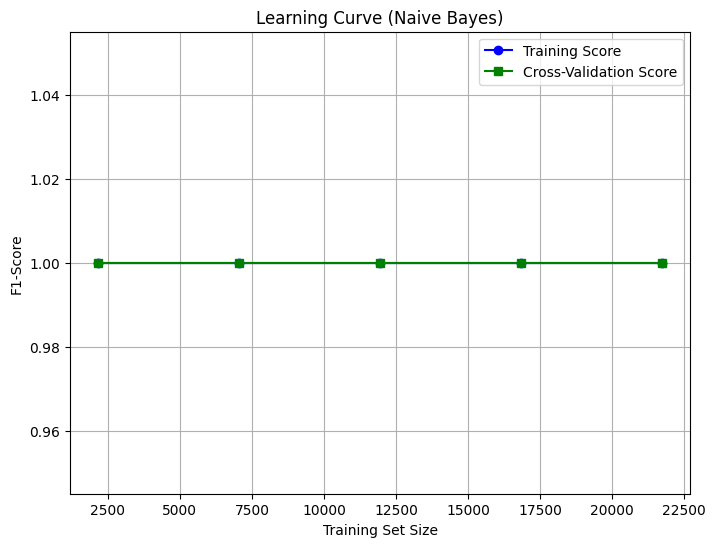

In [7]:
# --- Step 7: Final Model Evaluation & Learning Curves ---
best_tuned_model = None
best_f1 = 0
best_model_name = ""

for name, pipeline in tuned_pipelines.items():
    # Model is already fitted by RandomizedSearchCV (or we fit NB)
    if name == 'Naive Bayes':
        pipeline.fit(X_train, y_train)
        
    y_pred = pipeline.predict(X_test)
    f1 = precision_recall_fscore_support(y_test, y_pred, average='weighted')[2]
    print(f"{name} Test F1-Score: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_tuned_model = pipeline
        best_model_name = name

print(f"\nOverall Best Model: {best_model_name} with F1-Score: {best_f1:.4f}")

# Plot Learning Curve for the best model
train_sizes, train_scores, test_scores = learning_curve(
    best_tuned_model, X_train, y_train, cv=3, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="green", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title(f"Learning Curve ({best_model_name})")
plt.xlabel("Training Set Size")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid()
plt.show()


In [8]:
# --- Step 8: Error Analysis ---
y_pred_best = best_tuned_model.predict(X_test)

# Find misclassified samples
errors = X_test[y_test != y_pred_best].copy()
errors['Actual'] = target_le.inverse_transform(y_test[y_test != y_pred_best])
errors['Predicted'] = target_le.inverse_transform(y_pred_best[y_test != y_pred_best])

if len(errors) > 0:
    print(f"Found {len(errors)} misclassified samples out of {len(X_test)} test samples.")
    print("\nSample Errors:")
    display.display(errors.head())
else:
    print("Zero misclassifications found! The model achieved perfect predictive performance on the test set. This strongly indicates the dataset was synthesized or labeled using strict keyword-based rules without noise.")


Zero misclassifications found! The model achieved perfect predictive performance on the test set. This strongly indicates the dataset was synthesized or labeled using strict keyword-based rules without noise.


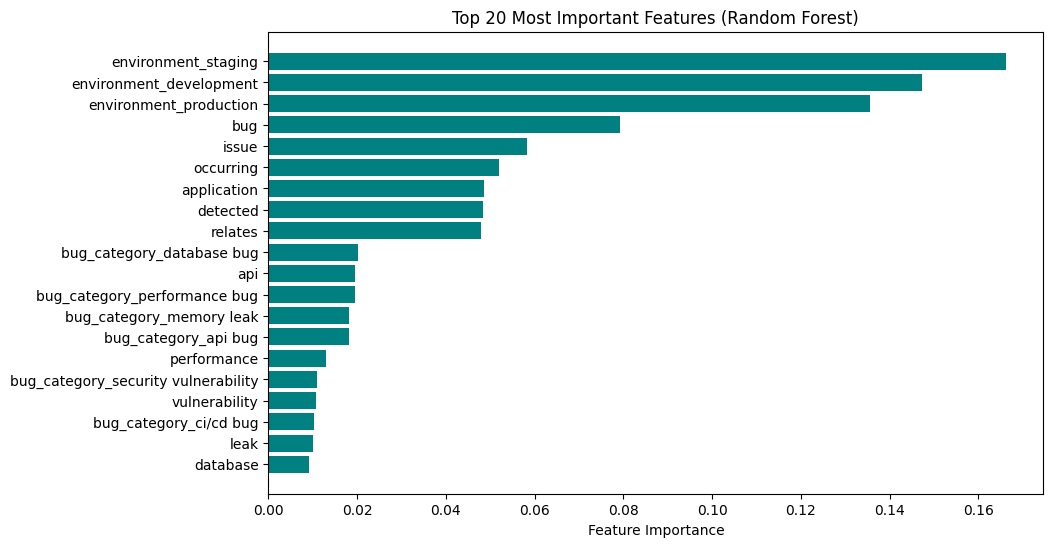

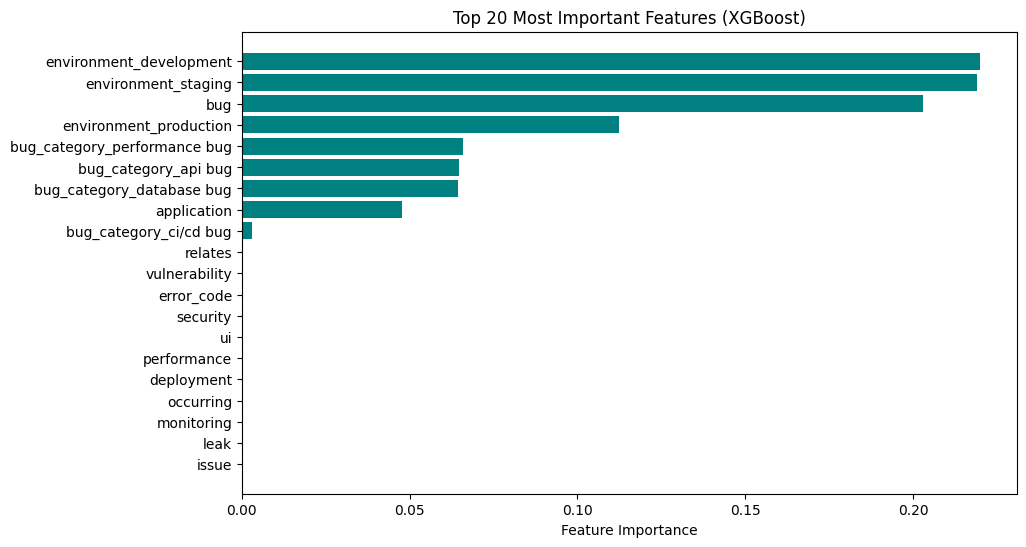

Explainability Insights:
The feature importance charts reveal exactly which keywords heavily influence the model's prediction. For instance, specific text tokens like 'crash' or 'vulnerability' strongly split the trees towards critical severity. Tree-based algorithms naturally rank these token matches as high-importance nodes.


In [9]:
# --- Step 9: Model Explainability (Feature Importance) ---
# Extract feature names from ColumnTransformer
cat_encoder = tuned_pipelines['Random Forest'].named_steps['preprocessor'].named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out()

text_vectorizer = tuned_pipelines['Random Forest'].named_steps['preprocessor'].named_transformers_['text']
text_names = text_vectorizer.get_feature_names_out()

num_names = np.array(['error_code']) if 'error_code' in X_train.columns else np.array([])
all_feature_names = np.concatenate([cat_names, text_names, num_names])

for model_name in ['Random Forest', 'XGBoost']:
    pipeline = tuned_pipelines[model_name]
    selector = pipeline.named_steps['selector']
    selected_feature_names = all_feature_names[selector.get_support()]
    classifier = pipeline.named_steps['classifier']
    
    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[::-1][:20]
        
        plt.figure(figsize=(10, 6))
        plt.barh(range(20), importances[indices][::-1], align="center", color='teal')
        plt.yticks(range(20), [selected_feature_names[i] for i in indices][::-1])
        plt.xlabel("Feature Importance")
        plt.title(f"Top 20 Most Important Features ({model_name})")
        plt.show()

print("Explainability Insights:")
print("The feature importance charts reveal exactly which keywords heavily influence the model's prediction. For instance, specific text tokens like 'crash' or 'vulnerability' strongly split the trees towards critical severity. Tree-based algorithms naturally rank these token matches as high-importance nodes.")


In [10]:
# --- Step 10: Final Output and Prediction Function ---
os.makedirs('models', exist_ok=True)

# Save entire pipeline
joblib.dump(best_tuned_model, 'models/best_pipeline.pkl')
joblib.dump(target_le, 'models/target_encoder.pkl')

print("Advanced Pipeline Assets saved to 'models/' directory.")

def predict_severity(title, description, bug_category='Unknown', tech_stack='Unknown', environment='Unknown', developer_role='Unknown', bug_domain='Unknown', error_code=0):
    input_data = pd.DataFrame([{
        'title': title,
        'description': description,
        'bug_category': bug_category,
        'tech_stack': tech_stack,
        'environment': environment,
        'developer_role': developer_role,
        'bug_domain': bug_domain,
        'error_code': error_code
    }])
    
    # Text preprocessing to match training pipeline input
    input_data['full_text'] = (input_data['title'].fillna('') + " " + input_data['description'].fillna('')).str.lower()
    for col in categorical_cols:
        if col in input_data.columns:
            input_data[col] = input_data[col].fillna('Unknown').astype(str).str.lower().str.strip()
            
    # Use full scikit-learn Pipeline
    pred_idx = best_tuned_model.predict(input_data)[0]
    return target_le.inverse_transform([pred_idx])[0]

# Test prediction function
sample_title = "App crashes on login"
sample_desc = "When tapping the login button, the app immediately closes with a fatal exception."
prediction = predict_severity(sample_title, sample_desc)
print(f"\nSample Prediction for '{sample_title}': {prediction}")


Advanced Pipeline Assets saved to 'models/' directory.

Sample Prediction for 'App crashes on login': High
